# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

Dataset yang digunakan dalam eksperimen ini adalah **Diabetes Health Indicators Dataset**. Dataset ini diperoleh secara langsung dari repositori publik Kaggle (tautan referensi: https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset).

Dataset ini merupakan hasil ekstraksi dari Behavioral Risk Factor Surveillance System (BRFSS) tahun 2015. Data ini memiliki total 253.680 baris observasi dan 22 fitur (termasuk variabel target). Mayoritas fitur merupakan data kategorikal, ordinal, maupun biner yang mempresentasikan status kesehatan, indikator gaya hidup, dan demografi responden.

Tujuan utama penggunaan dataset ini adalah untuk membangun model klasifikasi biner berdasarkan kolom target `Diabetes_binary`, di mana nilai 0 merepresentasikan pasien tanpa diabetes, dan nilai 1 merepresentasikan pasien pradiabetes atau diabetes. Target kelas memiliki ketidakseimbangan (class imbalance) yang signifikan sehingga memerlukan penanganan metrik yang tepat selama fase pemodelan.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [7]:
#Type your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import os

# Memastikan tampilan kolom pandas tidak terpotong
pd.set_option('display.max_columns', None)

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [8]:
# Menentukan path dataset raw
raw_data_path = 'diabetes_binary_health_indicators_BRFSS2015.csv'

# Memuat dataset
df = pd.read_csv(raw_data_path)

# Menampilkan 5 baris pertama dataset
print("Tampilan 5 baris pertama dataset:")
display(df.head())

# Menampilkan informasi umum dataset
print("\nInformasi Dataset:")
df.info()

Tampilan 5 baris pertama dataset:


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0



Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Jumlah nilai kosong pada tiap fitur:
Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Jumlah data duplikat: 24206


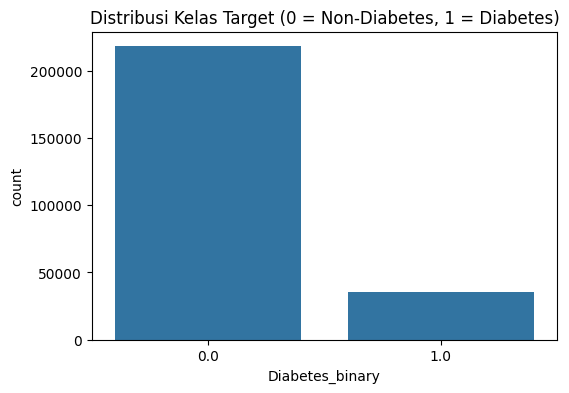


Catatan EDA: Terdapat ketidakseimbangan kelas yang parah pada target. Diperlukan metrik evaluasi seperti F1-Score atau implementasi class weight pada saat melatih model nanti.


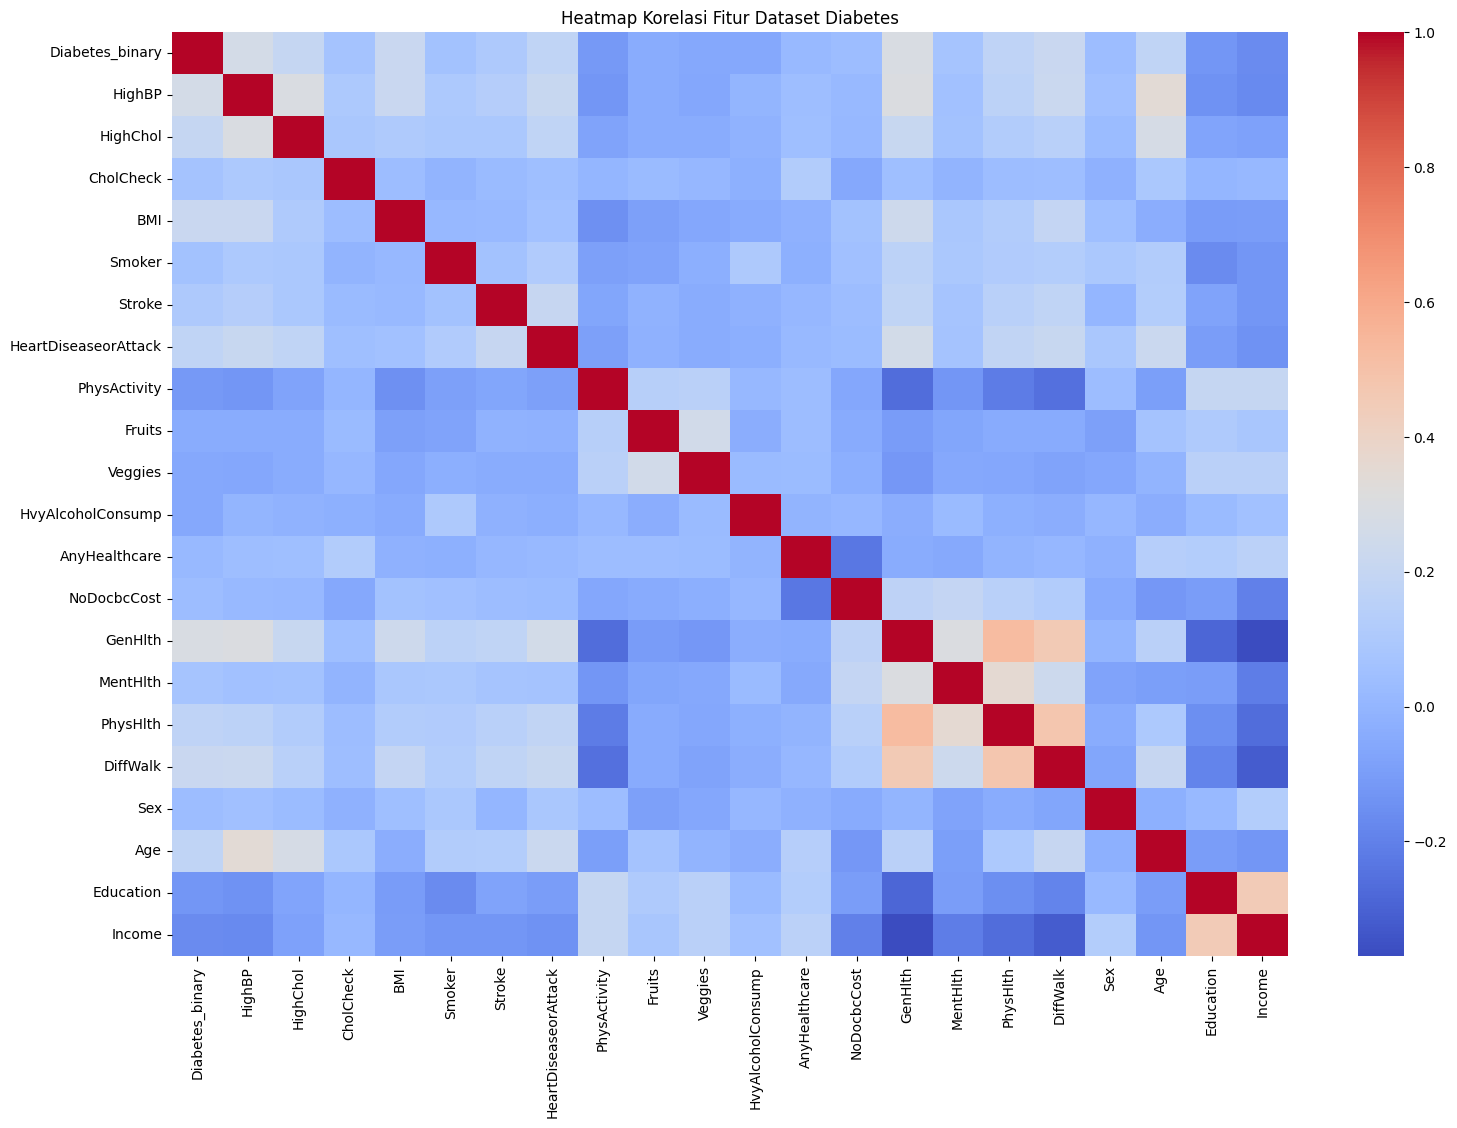

In [9]:
print("Jumlah nilai kosong pada tiap fitur:")
print(df.isnull().sum())

duplicate_count = df.duplicated().sum()
print(f"\nJumlah data duplikat: {duplicate_count}")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Diabetes_binary')
plt.title('Distribusi Kelas Target (0 = Non-Diabetes, 1 = Diabetes)')
plt.show()

print("\nCatatan EDA: Terdapat ketidakseimbangan kelas yang parah pada target. Diperlukan metrik evaluasi seperti F1-Score atau implementasi class weight pada saat melatih model nanti.")

plt.figure(figsize=(18, 12))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Fitur Dataset Diabetes')
plt.show()

# **5. Data Preprocessing**

# Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [10]:
print(f"Bentuk data sebelum drop duplicate: {df.shape}")
df_cleaned = df.drop_duplicates()
print(f"Bentuk data setelah drop duplicate: {df_cleaned.shape}")

scaler = MinMaxScaler()
columns_to_scale = ['BMI', 'MentHlth', 'PhysHlth']

df_cleaned[columns_to_scale] = scaler.fit_transform(df_cleaned[columns_to_scale])

output_folder = '../preprocessing/diabetes_preprocessing'
os.makedirs(output_folder, exist_ok=True)

output_path = os.path.join(output_folder, 'cleaned_diabetes_data.csv')
df_cleaned.to_csv(output_path, index=False)

print(f"\nData preprocessing selesai. Dataset bersih disimpan di: {output_path}")
display(df_cleaned.head())

Bentuk data sebelum drop duplicate: (253680, 22)
Bentuk data setelah drop duplicate: (229474, 22)


/tmp/ipykernel_844/2046071035.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[columns_to_scale] = scaler.fit_transform(df_cleaned[columns_to_scale])



Data preprocessing selesai. Dataset bersih disimpan di: ../preprocessing/diabetes_preprocessing/cleaned_diabetes_data.csv


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,0.325581,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,0.6,0.5,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,0.151163,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,0.186047,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,1.0,1.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,0.174419,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,0.139535,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.1,0.0,0.0,0.0,11.0,5.0,4.0
